In [2]:

from dataclasses import asdict

from src.agents.nodes.sql_generate_query_node import generate_sql_node
from utils.sql_tools import WmsSqlTool
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool, QuerySQLCheckerTool, InfoSQLDatabaseTool,ListSQLDatabaseTool
from langchain_google_genai import ChatGoogleGenerativeAI
from src.config import settings

_llm = None

def _getllm() -> ChatGoogleGenerativeAI:
    global _llm

    if _llm is None:
        _llm = ChatGoogleGenerativeAI(
            model=settings.GOOGLE_AI_MODEL,
            api_key=settings.GOOGLE_API_KEY,


        )
    return _llm
tools = WmsSqlTool(query_check_llm=_getllm())

query_tool = next(t for t in tools.get_sql_tools() if isinstance(t, QuerySQLDatabaseTool))
query_check = next(t for t in tools.get_sql_tools() if isinstance(t, QuerySQLCheckerTool))
list_tables = next(t for t in tools.get_sql_tools() if isinstance(t, ListSQLDatabaseTool))
list_info = next(t for t in tools.get_sql_tools() if isinstance(t, InfoSQLDatabaseTool))

res= list_info.invoke({"table_names": list_tables.invoke("")})


ImportError: cannot import name 'generate_sql_node' from 'src.agents.nodes.sql_generate_query_node' (/Users/rahul/Library/Mobile Documents/com~apple~CloudDocs/SCM_Agentic_Ai/WMS_Incident_Copilot/src/agents/nodes/sql_generate_query_node.py)

In [ ]:
res

In [ ]:
tool = tools.get_sql_tools()

next(t for t in tool if isinstance(t, QuerySQLDatabaseTool))

In [ ]:
from pprint import pprint
check_sql = "select * from inventory wher limit 10"
checked_sql = query_check.invoke({"query": check_sql})
pprint(checked_sql)


In [ ]:
from data.state import WMState
from agents.nodes.query_enrich_node import router_node

state = WMState(
    ticket_number= "INC12345",
    description= "how to slot sku003 and how much",
    user_id= "rahul"
)

router = router_node(state)

router


In [ ]:
from agents.graph.sql_subgraph import sql_graph
from domain.states.sql_subgraph_state.sql_graph_state import SQLGraphState
from dotenv import load_dotenv
load_dotenv()
state = SQLGraphState(

    description= "how many picks left?",
    domain="outbound"
)

router = sql_graph.invoke(state)

from rich.console import Console
from rich.markdown import Markdown
console = Console()

console.print(Markdown(router['final_response']))


In [ ]:
from langgraph.graph import StateGraph, START, END
from src.data.state import WMState
from IPython.display import display, Image
from src.agents.nodes.query_enrich_node import router_node
from agents.graph.sql_subgraph import sql_graph
from src.agents.nodes.sql_result_node import return_result_node
from src.agents.edges.router_intent_edge import router_intent_edge
from langgraph.cache.memory import InMemoryCache
from agents.nodes.supervisor_node import SupervisorNode
from agents.nodes.inbound_agent_node import inbound_agent_node
from agents.nodes.outbound_agent_node import outbound_agent_node
from agents.nodes.inventory_agent_node import inventory_agent_node
from dotenv import load_dotenv
load_dotenv()
builder = StateGraph(WMState)
supervisor_node = (SupervisorNode())

builder.add_node("router_node", router_node)
builder.add_node("sql_query_subgraph", sql_graph)
builder.add_node("return_result_node", return_result_node)
builder.add_node("supervisor_node", supervisor_node)
builder.add_node("inbound_agent_node", inbound_agent_node)
builder.add_node("outbound_agent_node", outbound_agent_node)
builder.add_node("inventory_agent_node", inventory_agent_node)


builder.add_edge(START, "router_node")
builder.add_conditional_edges(
    "router_node",
    router_intent_edge,
    {
        "lookup":"sql_query_subgraph",
        "diagnose": "supervisor_node"
    }
)
builder.add_conditional_edges(
    "supervisor_node",
    lambda state: ["inbound_agent_node", "outbound_agent_node", "inventory_agent_node"],
    {
        "inbound_agent_node": "inbound_agent_node",
        "outbound_agent_node": "outbound_agent_node",
        "inventory_agent_node": "inventory_agent_node",
    }
)

# Agents → back to supervisor
builder.add_edge("inbound_agent_node", "supervisor_node")
builder.add_edge("outbound_agent_node", "supervisor_node")
builder.add_edge("inventory_agent_node", "supervisor_node")

# Supervisor can also go to result
builder.add_edge("return_result_node", END)

graph = builder.compile(cache=InMemoryCache())

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
result = await graph.ainvoke(
    {
        "ticket_number": "INC12345",
        "description": "what all issues in inbound ?",
        "user_id": "rahul",
        "domain": "inventory",
    }
)

from rich.console import Console
from rich.markdown import Markdown

console = Console()

print(type(result))
print(result)

final_text = result.get("final_response") or str(result)
print("FINAL_TEXT:", repr(final_text))

console.print(Markdown(final_text))

In [ ]:


from langchain_core.messages import HumanMessage

from data.state import WMState
from models.model_loader import get_google_llm

get_google_llm().invoke([HumanMessage(content="Hello")]).content[0]["text"].strip()

In [3]:


from agents.nodes.supervisor_node import SupervisorNode
from data.state import WMState

message = (
   "picking is low and uph is low but invenotry is high why and also inbound has no work"
)

state = WMState(
    ticket_number="INC12345",
    description=message,
    user_id="rahul",
)


node = SupervisorNode()
response = await node(state)
print(response)


2026-04-13 22:47:49,018 | INFO | agents.nodes.inbound_agent_node | INBOUND AGENT CALLED
2026-04-13 22:47:49,031 | INFO | agents.nodes.outbound_agent_node | OUTBOUND AGENT CALLED
2026-04-13 22:47:49,038 | INFO | agents.nodes.inventory_agent_node | INVENTORY AGENT CALLED


ImportError: cannot import name 'SupervisorNode' from 'agents.nodes.supervisor_node' (/Users/rahul/Library/Mobile Documents/com~apple~CloudDocs/SCM_Agentic_Ai/WMS_Incident_Copilot/src/agents/nodes/supervisor_node.py)

In [ ]:
for data in response.goto:
    print(data)
    print("="*90)


In [ ]:
from agents.nodes.supervisor_node import SupervisorNode
from agents.nodes.inbound_agent_node import inbound_agent_node
from data.state import WMState, WorkerInput

AGENTS = {
    "inbound_agent": inbound_agent_node,
    # "outbound_agent": outbound_agent_node,
    # "inventory_agent": inventory_agent_node,
}

message = (
    "whats the over wms load"
)

state = WMState(
    ticket_number="INC12345",
    description=message,
    user_id="rahul",
)

supervisor = SupervisorNode()

# Run supervisor
cmd = await supervisor(state)
print("Supervisor returned:")
print(cmd)


In [ ]:
from agents.graph.sql_subgraph import sql_graph
from data.state import SQLGraphState
state2 = SQLGraphState(
    domain="outbound",
    description="how much left in picking outbound and what all skus"
)

res = sql_graph.invoke(state2)

res

In [ ]:
state2 = SQLGraphState(
    domain="outbound",
    description="how much sku do we need for picking"
)

res = sql_graph.invoke(state2)

res

In [ ]:
from models.model_loader import get_openai_fast_llm
from domain.states.supervisor.supervisor_subagent_task_state import SupervisorToSubAgentDeligationItem

llm = get_openai_fast_llm().with_structured_output(SupervisorToSubAgentDeligationItem)

response = llm.invoke([
    {"role": "system", "content": "You are a WMS diagnose agent elaborate issues in depth"},
    {"role": "user", "content": "whats my inbound issues"}
])

response

In [ ]:
for data in response.subagent_deligations:
    print(data.subagent_task)
    print("="*19)

In [ ]:
from agents.nodes.supervisor_node import SupervisorNode
from domain.states.supervisor.diagnose_graph_state import WMState

message = (
    "whats inbound staus"
)
state = WMState(
    ticket_number="INC12345",
    description=message,
)


node = SupervisorNode()
response = await node(state)
print(response)


# subagent_name= subagent_name,
#             worker_task=subagent_research_task,
#             task_id=str(task_id),
#             domain_name=domain,

In [ ]:
response.goto

In [ ]:
from langgraph.graph import StateGraph, START, END
from domain.states.supervisor.diagnose_graph_state import WMState
from IPython.display import display, Image
from src.agents.nodes.query_enrich_node import router_node
from agents.graph.sql_subgraph import sql_graph
from agents.edges.router_intent_edge import router_intent_edge
from agents.nodes.supervisor_node import WarehouseSupervisorNode
from agents.nodes.diagnose_result_node import diagnose_result_node
from agents.nodes.sql_lookup_subgraph_node import sql_query_subgraph_node
from dotenv import load_dotenv
load_dotenv()
builder = StateGraph(WMState)
supervisor_node = WarehouseSupervisorNode()

builder.add_node("router_node", router_node)
builder.add_node("sql_query_subgraph_node", sql_query_subgraph_node)

builder.add_node("supervisor_node", supervisor_node)
builder.add_node("diagnose_result_node", diagnose_result_node)

builder.add_edge(START, "router_node")

builder.add_conditional_edges(
    "router_node",
    router_intent_edge,
    {
        "lookup": "sql_query_subgraph_node",
        "diagnose": "supervisor_node",
    },
)

# lookup path ends here
builder.add_edge("sql_query_subgraph_node", END)

# diagnose_result_node is your explicit finish node
builder.add_edge("diagnose_result_node", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:

result = await graph.ainvoke(
    {
        "ticket_number":"INC12345",
        "description":"what status of inbound ?",
    }
)

from rich.console import Console
from rich.markdown import Markdown

console = Console()

print(type(result))
print(result)

final_text = result.get("final_responses") or str(result)

console.print(Markdown(final_text['final_responses']))

In [ ]:
final_text['final_responses']

In [ ]:
from agents.nodes.query_enrich_node import router_node
from domain.states.supervisor.diagnose_graph_state import WMState

state = WMState(
    ticket_number="INC12345",
    description="what is the sttus of sku 003",
    session_id="rahul"
)

res = router_node(state)

print(res)

In [ ]:
from langgraph.graph import StateGraph
from domain.states.sql_subgraph_state.sql_graph_state import SQLGraphState
from IPython.display import display, Image
from domain.states.sql_subgraph_state.sql_graph_state import SQLGraphState
from src.agents.nodes.sql_load_skills_node import sql_load_skills_node
from src.agents.nodes.sql_generate_query_node import sql_generate_query_node
from src.agents.nodes.check_sql_node import check_sql_node
from src.agents.nodes.sql_run_sql_node import sql_run_sql_node
from src.agents.nodes.sql_result_node import sql_result_node
from langgraph.graph import StateGraph, START, END

sql_graph_state = StateGraph(SQLGraphState)
builder = sql_graph_state.add_sequence([
        sql_load_skills_node,
        sql_generate_query_node,
        check_sql_node,
        sql_run_sql_node,
        sql_result_node,
    ])

sql_graph_state.add_edge(START, "sql_load_skills_node")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
example = SQLGraphState(
    domain="outbound",
    user_question="whats the total picks left?",
)

result = graph.invoke(example)

import pandas as pd

df = pd.DataFrame(result.get('result').rows)
df

In [ ]:
result.get('result').rows

In [ ]:
from runtime.session_runtime import WMSSessionRuntime
from agents.graph.application_graph import graph
runtime = WMSSessionRuntime(graph)

# First run
result = await runtime.run(
    session_id="prajwal",
    ticket_number="INC123454343",
    description="how much sku 004 i have?"
)

# Second run — same session, history saved
# result = await runtime.run(
#     session_id="rahul",
#     user_input="now check outbound picking"
# )
print(result)

In [ ]:
resultt = await runtime.run(
    session_id="prajwal",
    ticket_number="INC123454343",
    description="how much sku 004 i have?"
)
result


In [ ]:
from agents.graph.application_graph import graph

graph = graph

res = graph.invoke({
     "ticket_number":"INC12345",
    "session_id":"manju",
    "user_id":"manju",
    "description":"can i get steps for putaway from inbound",
}, config={"configurable": {"thread_id":"manju"}})

In [ ]:
from rich.markdown import Markdown
from rich.console import  Console

console = Console()

console.print(Markdown(''.join(res.get("diagnosis_result").citations)))


In [ ]:
config={"configurable": {"thread_id":"manju"}}
history = list(graph.get_state_history(config))

for i, s in enumerate(history):
    print(f"\n--- checkpoint {i} ---")
    print("config:", s.config)
    print("next:", s.next)
    print("values:", s.values)  # includes checkpoint info

In [ ]:
history = list(graph.get_state_history(config))
old_snapshot = history[7]   # example: choose one checkpoint

replay_result = graph.invoke(None, old_snapshot.config)
print(replay_result)

In [ ]:
from agents.nodes.supervisor_node import WarehouseSupervisorNode
from domain.states.supervisor.diagnose_graph_state import WMState

WarehouseSupervisorNode().__call__(WMState(
        description="whats the methos to palletize inboudn inventory ",
        ticket_number="INC2003",
        user_id="rahul",
        session_id="Rahul"

    ))

2026-04-14 22:49:11,008 | INFO | agents.nodes.inbound_agent_node | INBOUND AGENT CALLED
2026-04-14 22:49:11,019 | INFO | agents.nodes.outbound_agent_node | OUTBOUND AGENT CALLED
2026-04-14 22:49:11,027 | INFO | agents.nodes.inventory_agent_node | INVENTORY AGENT CALLED


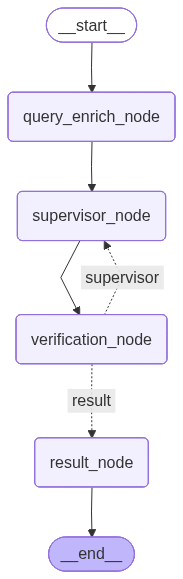

In [1]:
from functools import lru_cache
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from domain.states.supervisor.diagnose_graph_state import WMState
from agents.nodes.supervisor_node import WarehouseSupervisorNode
from agents.nodes.verification_node import verification_node
from agents.nodes.query_enrich_node import query_enrich_node
from agents.nodes.result_node import result_node
from agents.edges.verification_router import route_after_verification
from IPython.display import display, Image

supervisor_node = WarehouseSupervisorNode()

@lru_cache(maxsize=1)
def _application_graph():
    builder = StateGraph(WMState)

    builder.add_node("query_enrich_node", query_enrich_node)
    builder.add_node("supervisor_node", supervisor_node)
    builder.add_node("verification_node", verification_node)
    builder.add_node("result_node", result_node)

    builder.add_edge(START, "query_enrich_node")
    builder.add_edge("query_enrich_node", "supervisor_node")
    builder.add_edge("supervisor_node", "verification_node")

    builder.add_conditional_edges(
        "verification_node",
        route_after_verification,
        {
            "supervisor": "supervisor_node",
            "result": "result_node",
        },
    )
    # builder.add_edge("supervisor_node", "result_node")
    builder.add_edge("result_node", END)
    return builder

_application_graph.cache_clear()
checkpointer = InMemorySaver()
graph = _application_graph().compile(checkpointer=checkpointer)

display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
from domain.states.supervisor.diagnose_graph_state import WMState

data = graph.invoke(
    WMState(
        description="how to putaway inbound inventory?",
        session_id="example",
        ticket_number="INC",
        user_id="rahul",
    ),
    config={
        "configurable": {
            "thread_id": "example"
        }
    }
)

print(data)

2026-04-14 22:49:16,419 | INFO | httpx | HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
2026-04-14 22:49:34,310 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-14 22:49:36,059 | INFO | httpx | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
/Users/rahul/Library/Mobile Documents/com~apple~CloudDocs/SCM_Agentic_Ai/WMS_Incident_Copilot/.venv/lib/python3.12/site-packages/langchain_classic/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_e

{'ticket_number': 'INC', 'session_id': 'example', 'user_id': 'rahul', 'description': 'Describe the inbound inventory putaway workflow in the WMS. Include how receipts link to a Purchase Order (PO) or Advanced Shipment Notice (ASN), how a putaway task is generated and assigned, how putaway locations (zone and position) are selected, how the goods are physically moved to storage, and how the system updates on-hand quantities and location accuracy. Mention dock appointments, inbound shipments, receipts, and how to handle common exceptions (receiving discrepancies, holds, or misplacement) during putaway.', 'status': 'done', 'event_log': [{'node': 'supervisor_node', 'status': 'completed'}, {'node': 'supervisor_node', 'status': 'completed'}, {'node': 'supervisor_node', 'status': 'completed'}], 'errors': [], 'current_node': 'start', 'loop_count': 0, 'max_turns': 0, 'final': True, 'task_description': None, 'messages': [], 'routing_decision': ['inbound', 'inventory'], 'lookup_result': None, 're

In [3]:
from rich.markdown import Markdown
from rich.console import Console
console = Console()

data.get('evidence_records')

[EvidenceRecord(evidence_id='sop:1', source='sop', content={'parents': [{'text': '1 Effective Receiving Practices \n1.1 Receiving Practices, Including Receiving Checklist \nEffective receiving practices are important aspects of successful warehousing.  \nReceiving must involve both the front office staff and warehouse personnel to \neffectively receive and track inbound products.   \nA receiving checklist is provided in Chapter 8 of this manual. \nFront Office: \nThe receiving process usually begins when the customer or carrier notifies the \nwarehouse of an inbound shipment and the warehouse schedules the delivery for a \nspecific day and time.   \nData Collection & Receiving Dock Notification: \nNormally, the front office personnel will receive or gather information specific to each \nload, including but not limited to: \no Purchase order number \no Load weight \no Number of cases or containers \no Number of different items \no Type of loading (pallets, slip sheets, floor loaded) \no

In [1]:
from copy import deepcopy
from domain.states.supervisor.diagnose_graph_state import WMState
from agents.nodes.router_node import router_node
from agents.nodes.parallel_execution_node import plan_parallel_subtask_node
from dataclasses import asdict

state = WMState(
    description="how much work i have left in outbound, inbound?",
    ticket_number="INC2003",
    user_id="rahul",
    session_id="Rahul"
)

router = router_node(state=state)   # likely returns dict
print(router)
state2 = WMState(
    **{**asdict(state), **deepcopy(router)}
)

parallel = plan_parallel_subtask_node(state2)
print(parallel)

{'task': 'parallel', 'enriched_query': 'What is the remaining workload for inbound and outbound operations?'}
{'subtasks': [SubTask(query='What is the remaining workload for inbound operations?', tool='sql_lookup_tool', domain='inbound'), SubTask(query='What is the remaining workload for outbound operations?', tool='sql_lookup_tool', domain='outbound')]}


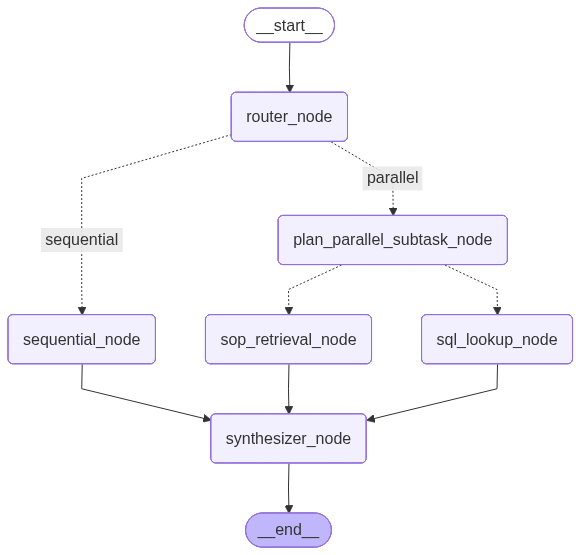

In [1]:
from functools import lru_cache
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import display, Image

from domain.states.supervisor.diagnose_graph_state import WMState
from agents.nodes.router_node import router_node
from agents.nodes.parallel_execution_node import plan_parallel_subtask_node
from agents.nodes.sql_lookup_node import sql_lookup_node
from agents.nodes.sop_lookup_node import sop_lookup_node
from agents.nodes.synthesizer_node import synthesizer_node
from agents.edges.fan_out_edge import fan_out_edge
from agents.edges.route_after_router import route_after_router
from agents.nodes.sequential_agent import sequential_agent


@lru_cache(maxsize=1)
def _application_graph():
    builder = StateGraph(WMState)

    # Nodes
    builder.add_node("router_node", router_node)
    builder.add_node("plan_parallel_subtask_node", plan_parallel_subtask_node)
    builder.add_node("sql_lookup_node", sql_lookup_node)
    builder.add_node("sop_retrieval_node", sop_lookup_node)
    builder.add_node("synthesizer_node", synthesizer_node)
    builder.add_node("sequential_node", sequential_agent)

    # Entry point
    builder.add_edge(START, "router_node")

    # Router decides: parallel (for now only path) — sequential path to be added later
    builder.add_conditional_edges(
        "router_node",
        route_after_router,
        {
            "parallel": "plan_parallel_subtask_node",
            "sequential": "sequential_node",
            # "sequential": "react_agent_node",  # add when sequential path is built
        },
    )

    # Planner → fan-out to workers (parallel execution)
    builder.add_conditional_edges(
        "plan_parallel_subtask_node",
        fan_out_edge,
        ["sql_lookup_node", "sop_retrieval_node"],
    )

    # Workers → synthesizer (barrier: waits for ALL parallel workers)
    builder.add_edge("sql_lookup_node", "synthesizer_node")
    builder.add_edge("sop_retrieval_node", "synthesizer_node")
    builder.add_edge("sequential_node", "synthesizer_node")

    # Synthesizer → END
    builder.add_edge("synthesizer_node", END)

    return builder


_application_graph.cache_clear()
checkpointer = InMemorySaver()
graph = _application_graph().compile(checkpointer=checkpointer)

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
import uuid

data = await graph.ainvoke(
    WMState(
        ticket_number="INC",
        session_id="example",
        user_id="rahul",
        description="how to putaway inbound pallet? ",
    ),
    config={"configurable": {"thread_id": str(uuid.uuid4().hex[:5])}},
)

data['sequential_results'] or data['parallel_results']

2026-04-18 23:38:07,415 | INFO | agents.nodes.router_node | task='parallel' enriched_query='What is the standard operating procedure for the putaway process of inbound pallets?'
2026-04-18 23:38:07,416 | INFO | agents.edges.route_after_router | Routing to PARALLEL path (ticket=INC, query=What is the standard operating procedure for the putaway process of inbound pallets?)
2026-04-18 23:38:07,425 | INFO | google_genai.models | AFC is enabled with max remote calls: 10.
2026-04-18 23:38:07,840 | INFO | httpx | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite-preview:generateContent "HTTP/1.1 503 Service Unavailable"
2026-04-18 23:38:07,847 | INFO | agents.nodes.sop_lookup_node | Sop lookup query: What is the standard operating procedure for the inbound putaway process for pallets?


[{'source': 'sop_retrieval_tool',
  'query': 'What is the standard operating procedure for the inbound putaway process for pallets?',
  'status': 'success',
  'result': [{'text': '1 Effective Receiving Practices \n1.1 Receiving Practices, Including Receiving Checklist \nEffective receiving practices are important aspects of successful warehousing.  \nReceiving must involve both the front office staff and warehouse personnel to \neffectively receive and track inbound products.   \nA receiving checklist is provided in Chapter 8 of this manual. \nFront Office: \nThe receiving process usually begins when the customer or carrier notifies the \nwarehouse of an inbound shipment and the warehouse schedules the delivery for a \nspecific day and time.   \nData Collection & Receiving Dock Notification: \nNormally, the front office personnel will receive or gather information specific to each \nload, including but not limited to: \no Purchase order number \no Load weight \no Number of cases or con